

---


 **Classification with Multiple Labels using MultiLayer Perceptrons using Scikit-learn**


---



In [ ]:
# Run this block only if you're using the notebook on a local machine
! pip install numpy
! pip install scikit-learn
! pip install matplotlib
! pip install tensorflow

In [ ]:
# Import the libraries
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from tensorflow import keras # For this network just to import the dataset MNIST

**Loading data (KERAS handwritten numbers dataset)**

In [ ]:
# MNIST dataset loading from Keras library

# Load the the data, split between train and test sets
(x_train_raw, y_train), (x_test_raw, y_test) = keras.datasets.mnist.load_data()

# Find the class number
num_classes = len(set(y_train))
print("Class number:", num_classes)

# Print data type and shape
print("Data type:", type(x_train_raw))
print("Data shape:", x_train_raw.shape)

# Print data labels type and shape
print("Data labels type:", type(y_train))
print("Data labels shape:", y_train.shape)


**Visualize the data**

In [ ]:
# Visualize the dataset (draw the images)
import matplotlib.pyplot as plt

def draw_N(data, N, figsize):
    plt.figure(figsize=(figsize, figsize))
    for i,image in enumerate(data[:N**2]):
        plt.subplot(N, N, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(image, cmap=plt.cm.binary)
    plt.show()

draw_N(data=x_train_raw, N=4, figsize=8)

**Data reshape**

MLPs do not understand such things as '2D'. To give that type of data as input to the neural network, we need to convert each image of size 28x28 (2d-vector) into a 1D vector of 1x784. After the rehape process, each image can be considered a dataset record made by 784 features.

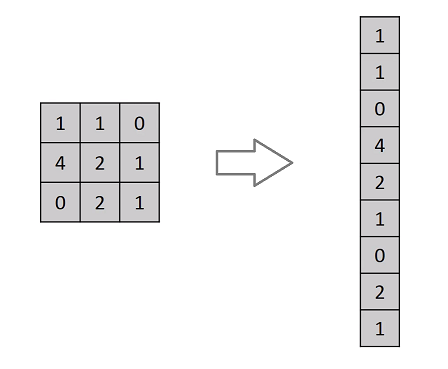

In [ ]:
import numpy as np
import math

# Reshape data
feature_vector_length = math.prod(x_train_raw.shape[1:])
x_train = x_train_raw.reshape(x_train_raw.shape[0], feature_vector_length)
x_test = x_test_raw.reshape(x_test_raw.shape[0], feature_vector_length)

# Print the new shape
print("New training data shape:", x_train.shape)
print("New test data shape:", x_test.shape)

# Max and min values on the dataset
print("Max pixel values:", np.max(x_train))
print("Min pixel values:", np.min(x_train))

# Print an image as a 1D vector
print(x_train[0])


**Normalize the data**

In [ ]:
# Since NN works better with numbers in [0,1], a normalization step is always suggested 

from sklearn.preprocessing import MinMaxScaler

# Create the features scaler
minmax = MinMaxScaler()

# Normalize the dataset
x_train_norm = minmax.fit_transform(x_train)
x_test_norm = minmax.fit_transform(x_test)

# Max and min values on the dataset
print("Max pixel values:", np.max(x_train_norm))
print("Min pixel values:", np.min(x_train_norm))

# Show the normalized data
print(x_train_norm[0])


**Let's train a MLP using sklearn**

[Click here to open the MLP documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

In [ ]:
# Create a simple MLP model
mlp1 = MLPClassifier(
    solver='adam',
    activation='relu',
    hidden_layer_sizes=(),
    max_iter=75,
    random_state=1,
    verbose=True
)
mlp1.fit(x_train_norm, y_train)

In [ ]:
# Create another MLP model
mlp2 = MLPClassifier(
    solver='adam',
    activation='relu',
    hidden_layer_sizes=(128, 32),
    max_iter=50,
    random_state=1,
    verbose=True
)
mlp2.fit(x_train_norm, y_train)

**Making predictions**

In [ ]:
# Predict the number in the image
y_pred1 = mlp1.predict(x_test_norm)
y_pred2 = mlp2.predict(x_test_norm)

print("MLP1:", y_pred1[:20])
print("MLP2:", y_pred2[:20])
print("Real:", y_test[:20])

In [ ]:
# Let's draw the misclassified image by MLP1
import matplotlib.pyplot as plt

# Make sure to reshape the vector back to it's original shape in order to be able to visualize it.
x_test_vis = x_test_norm.reshape(x_test_norm.shape[0], 28, 28)
print("Shape:", x_test_vis.shape)
print("Label:", y_test[8])
plt.imshow(x_test_vis[8], cmap='Greys')
plt.show()

**Model evalution**

In [ ]:
# Check the accuracy values
print("Accuracy of MLP1:", metrics.accuracy_score(y_test, y_pred1))
print("Accuracy of MLP2:", metrics.accuracy_score(y_test, y_pred2))

In [ ]:
import random

# Check the loss curve of the models
def draw_loss(*MLPs):
    losses = [m.loss_curve_ for m in MLPs]
    max_len = max(map(len, losses))
    losses = [l + l[-1:] * (max_len - len(l)) for l in losses]
    for i, l in enumerate(losses, start=1):
        plt.plot(l, color=(random.random(), random.random(), random.random()), label=f"MLP-{i}")
    plt.title("Loss curves")
    plt.legend()
    plt.show()

draw_loss(mlp1, mlp2)

**Cross-validation**

In [ ]:
from sklearn.model_selection import cross_val_score

scores1 = cross_val_score(mlp1, x_test_norm, y_test, cv=10)
scores2 = cross_val_score(mlp2, x_test_norm, y_test, cv=10)

In [ ]:
# Print the cross validation score of the 2 models
print("CV scores (MLP1):", scores1)
print("Mean accuracy value (MLP1):", scores1.mean())

print("CV scores (MLP2):", scores2)
print("Mean accuracy value (MLP2):", scores2.mean())

**Plotting the confusion matrix**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Function to draw the confusion matrix
def plot_confusion_matrix(cm, labels):
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    display.plot(cmap=plt.cm.Blues)
    plt.title("Confusion matrix")
    plt.show()

In [ ]:
# Compute the confusion matrix for MLP1
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test, y_pred1)
print(cm1)
plot_confusion_matrix(cm1, range(num_classes))

In [ ]:
# Compute the confusion matrix for MLP2
cm2 = confusion_matrix(y_test, y_pred2)
print(cm2)
plot_confusion_matrix(cm2, range(num_classes))

**The overfitting problem**

In [ ]:
from sklearn.metrics import log_loss

# Train a MLP, then return the training and test loss
def fit_and_draw_loss(mlp, x_train, y_train, x_test, y_test, max_iter, verbose=0):
    train_losses = []
    test_losses = []
    for i in range(1, max_iter + 1):
        if verbose > 0: print(f"Iteration {i}", end='' if verbose > 1 else '\n')
        mlp.partial_fit(x_train, y_train, classes=np.unique(y_train))

        train_pred = mlp.predict_proba(x_train)
        train_loss = log_loss(y_train, train_pred)
        train_losses.append(train_loss)
        
        test_pred = mlp.predict_proba(x_test)
        test_loss = log_loss(y_test, test_pred)
        test_losses.append(test_loss)
        if verbose > 1: print(f": {train_loss=}, {test_loss=}")
    return train_losses, test_losses

# Draw the losses over the training epochs
def draw_train_and_test_loss(train_losses, test_losses):
    plt.plot(train_losses, color="red", label="train loss")
    plt.plot(test_losses, color="blue", label="test loss")
    plt.title("Loss curves comparison")
    plt.legend()
    plt.show()

In [ ]:
# Let's test a simple model
mlp3 = MLPClassifier(
    solver='adam',
    activation='relu',
    hidden_layer_sizes=(),
    random_state=1,
    verbose=False
)

# Fit and draw train and test loss values
train_loss, test_loss = fit_and_draw_loss(mlp3, x_train_norm, y_train, x_test_norm, y_test, max_iter=40, verbose=2)
draw_train_and_test_loss(train_loss, test_loss)

In [ ]:
# Let's test a more complex model
mlp4 = MLPClassifier(
    solver='adam',
    activation='relu',
    hidden_layer_sizes=(64, 32),
    random_state=1,
    verbose=False
)

# Fit and draw train and test loss values
train_loss, test_loss = fit_and_draw_loss(mlp4, x_train_norm, y_train, x_test_norm, y_test, max_iter=40, verbose=2)
draw_train_and_test_loss(train_loss, test_loss)